<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [7]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-05-21 03:22:10--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.3’

survey-data.csv.3   100%[===================>] 152.13M  8.98MB/s    in 16s     
2026-05-21 03:22:28 (9.28 MB/s) - ‘survey-data.csv.3’ saved [159525875/159525875]


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [8]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [9]:
# Read the CSV file

df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [10]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)



65437

**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [6]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [7]:
QUERY = """SELECT COUNT(*) FROM main """
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [ ]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [ ]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


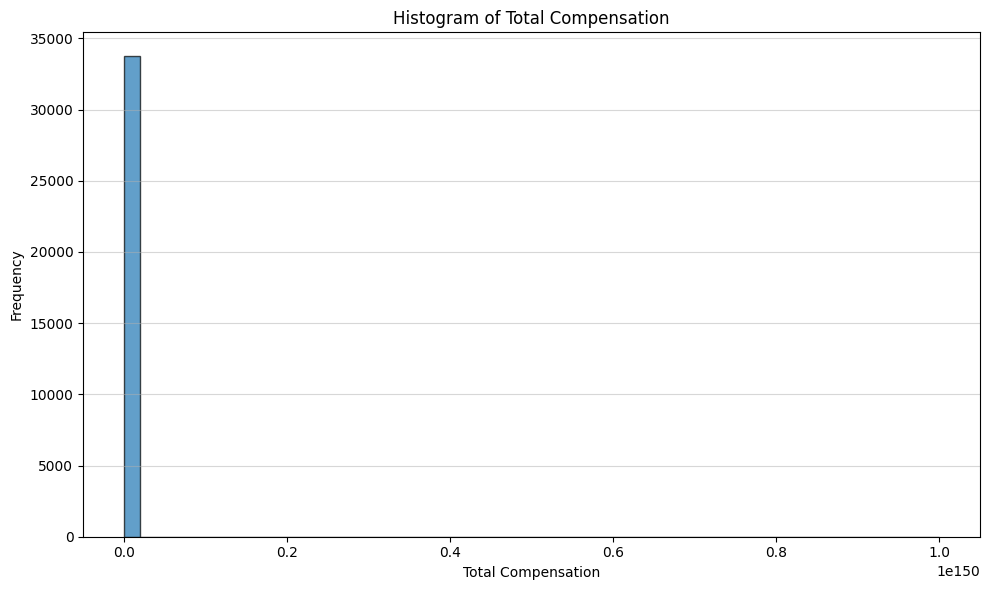

In [16]:
# Retrieve the pertinent column from the SQLite database
import pandas as pd
import matplotlib.pyplot as plt
QUERY = 'SELECT CompTotal FROM main'
df_hist = pd.read_sql_query(QUERY, conn)

# Construct the histogram utilizing matplotlib
plt.figure(figsize=(10, 6))
plt.hist(df_hist['CompTotal'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.title('Histogram of Total Compensation')
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

**Box Plots**

Plot a box plot of Age.


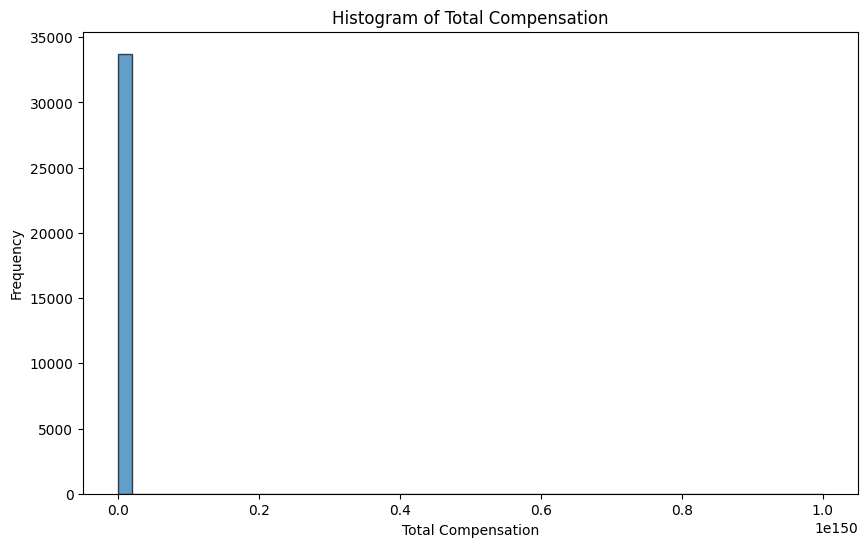

In [11]:
# Retrieve the Age column from the database
QUERY = 'SELECT Age FROM main'
df_age = pd.read_sql_query(QUERY, conn)

# Define the ordered age categories
age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old',
    '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older'
]

# Map age categories to numeric midpoints for box plot
age_midpoints = {
    'Under 18 years old': 16, '18-24 years old': 21, '25-34 years old': 29,
    '35-44 years old': 39, '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 68
}
df_age['Age_Num'] = df_age['Age'].map(age_midpoints)
age_numeric = df_age['Age_Num'].dropna()

# Plot box plot
plt.figure(figsize=(8, 6))
plt.boxplot(age_numeric, vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
plt.title('Box Plot of Age Distribution')
plt.ylabel('Age (numeric midpoint of category)')
plt.xlabel('Age')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


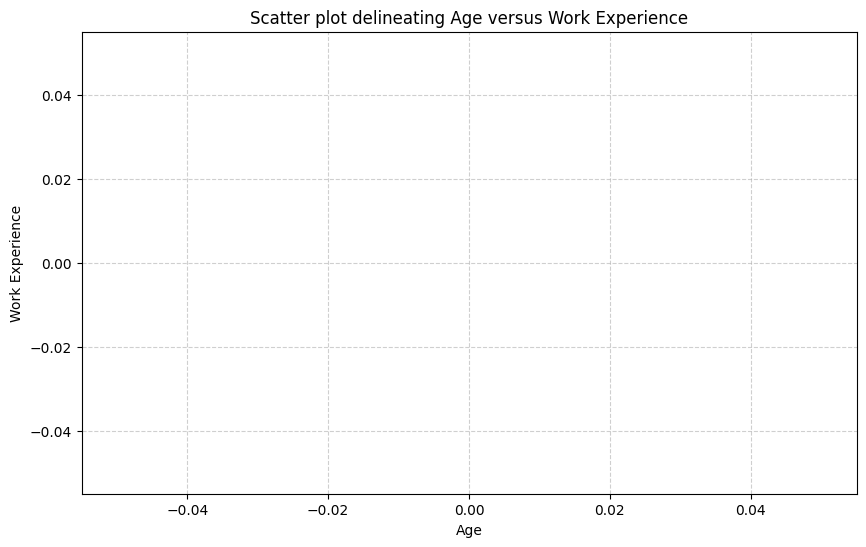

In [12]:
# Query age and work experience from the database
QUERY = 'SELECT Age, WorkExp FROM main WHERE WorkExp IS NOT NULL'
df_scatter = pd.read_sql_query(QUERY, conn)

# Map age categories to numeric midpoints
age_midpoints = {
    'Under 18 years old': 16, '18-24 years old': 21, '25-34 years old': 29,
    '35-44 years old': 39, '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 68
}
df_scatter['Age_Num'] = df_scatter['Age'].map(age_midpoints)
df_scatter = df_scatter.dropna()

# Sample for visual clarity
sample = df_scatter.sample(min(3000, len(df_scatter)), random_state=42)

# Render the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(sample['Age_Num'], sample['WorkExp'], alpha=0.3,
            edgecolor='none', color='steelblue')
plt.title('Scatter Plot of Age vs. Work Experience')
plt.xlabel('Age (midpoint of category)')
plt.ylabel('Years of Work Experience')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


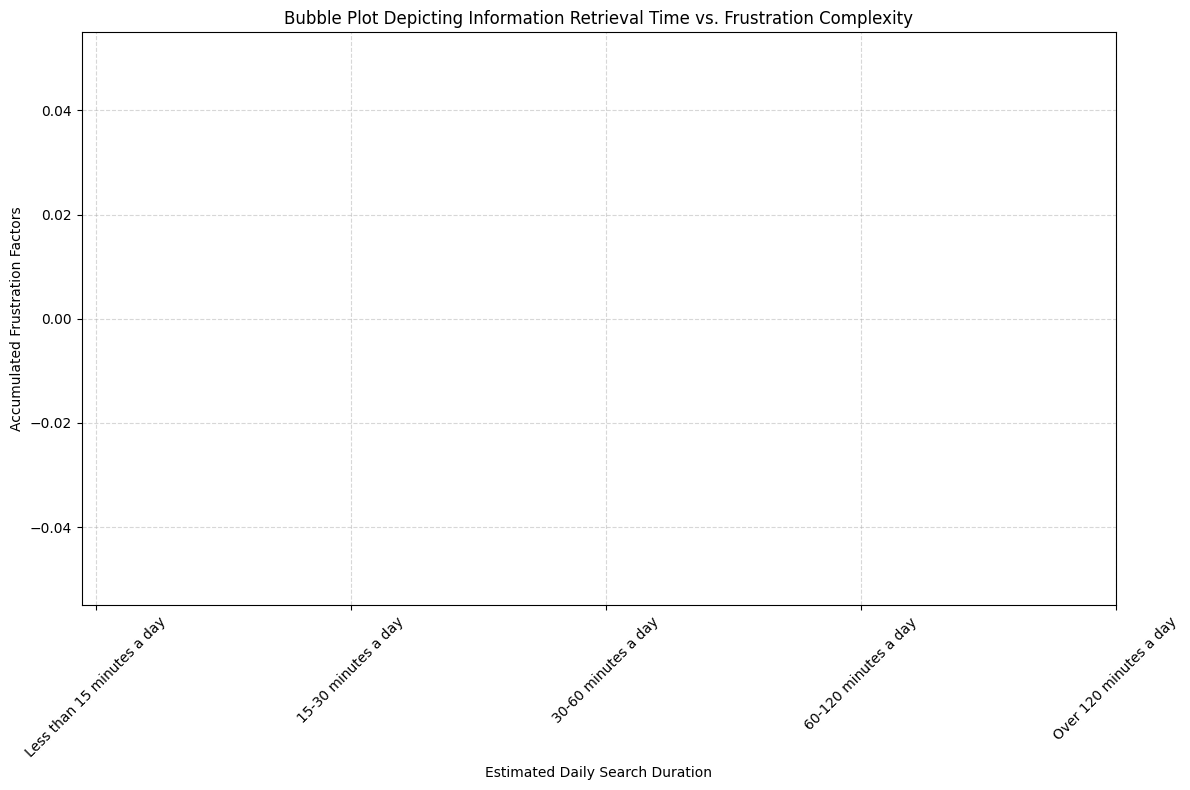

In [20]:
# Query the relevant columns
QUERY = 'SELECT TimeSearching, Frustration, Age FROM main WHERE TimeSearching IS NOT NULL AND Frustration IS NOT NULL'
df = pd.read_sql_query(QUERY, conn)

# Map time-searching categories to numeric values
time_categories = [
    'Less than 15 minutes', '15-30 minutes',
    '30-60 minutes', '60-120 minutes', 'Over 120 minutes'
]
time_map = {v: i for i, v in enumerate(time_categories)}
df['Time_Numeric'] = df['TimeSearching'].map(time_map)

# Robustly quantify frustration by counting semicolon-delimited items
df['Frustration_Index'] = df['Frustration'].apply(
    lambda x: 0 if pd.isna(x) or x == 'None of these' else str(x).count(';') + 1
)

# Map age to numeric and impute missing values
age_midpoints = {
    'Under 18 years old': 16, '18-24 years old': 21, '25-34 years old': 29,
    '35-44 years old': 39, '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 68
}
df['Age_Num'] = df['Age'].map(age_midpoints)
df['Age_Num'] = df['Age_Num'].fillna(df['Age_Num'].median())

# Extract valid entries and sample for readability
df_plot = df[df['Time_Numeric'] >= 0].dropna(subset=['Age_Num'])
sample_bubble = df_plot.sample(min(2000, len(df_plot)), random_state=42)

# Render the bubble visualization
plt.figure(figsize=(12, 8))
plt.scatter(
    x=sample_bubble['Time_Numeric'],
    y=sample_bubble['Frustration_Index'],
    s=sample_bubble['Age_Num'] * 3,
    alpha=0.6,
    edgecolor='black',
    c='teal'
)
plt.xticks(ticks=range(len(time_categories)), labels=time_categories, rotation=45)
plt.title('Bubble Plot Depicting Information Retrieval Time vs. Frustration Complexity')
plt.xlabel('Estimated Daily Search Duration')
plt.ylabel('Accumulated Frustration Factors')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


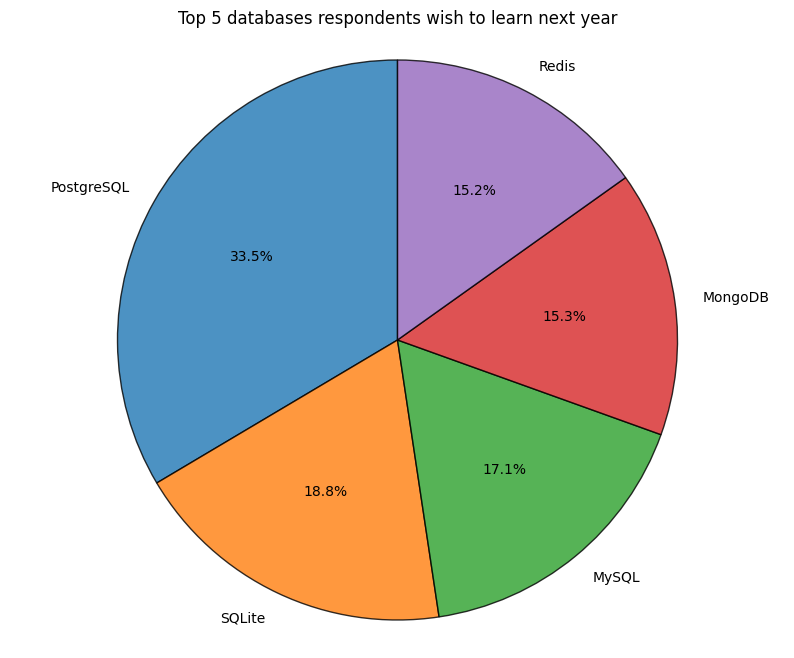

In [21]:
# Query DatabaseWantToWorkWith from the database
QUERY = 'SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL'
df_db = pd.read_sql_query(QUERY, conn)

# Split semicolon-delimited responses and count each database
all_dbs = []
for row in df_db['DatabaseWantToWorkWith']:
    all_dbs.extend(str(row).split(';'))
db_series = pd.Series(all_dbs).str.strip()
top5 = db_series.value_counts().head(5)

# Render the pie chart
plt.figure(figsize=(8, 8))
plt.pie(top5, labels=top5.index, autopct='%1.1f%%',
        startangle=140, colors=plt.cm.Set2.colors[:5])
plt.title('Top 5 Databases Respondents Want to Work With')
plt.tight_layout()
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


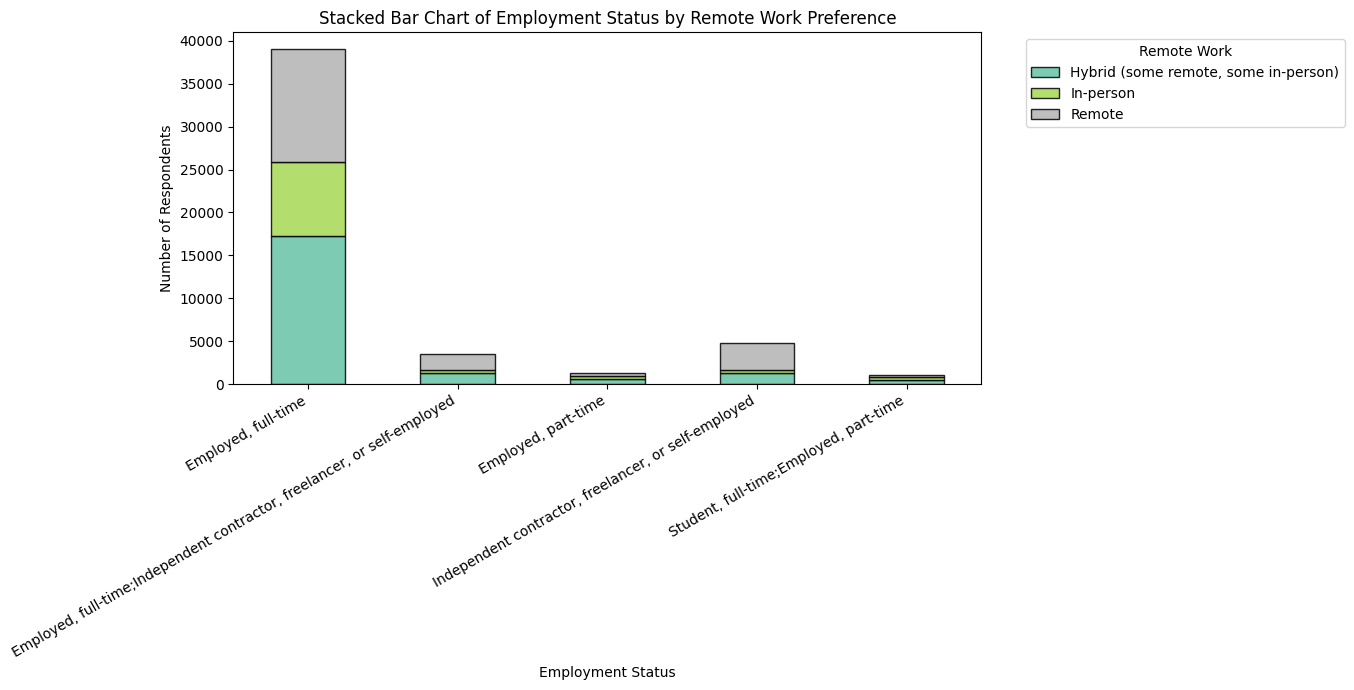

In [15]:
# Query employment and remote work columns
QUERY = 'SELECT Employment, RemoteWork FROM main WHERE Employment IS NOT NULL AND RemoteWork IS NOT NULL'
df_emp = pd.read_sql_query(QUERY, conn)

# Build pivot table — keep top 5 employment categories for readability
pivot = df_emp.groupby(['Employment', 'RemoteWork']).size().unstack(fill_value=0)
top_emp = df_emp['Employment'].value_counts().head(5).index
pivot = pivot.loc[pivot.index.isin(top_emp)]

# Render the stacked bar chart
pivot.plot(kind='bar', stacked=True, figsize=(13, 7),
           colormap='Set2', edgecolor='black', alpha=0.85)
plt.title('Stacked Bar Chart of Employment Status by Remote Work Preference')
plt.xlabel('Employment Status')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Remote Work', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


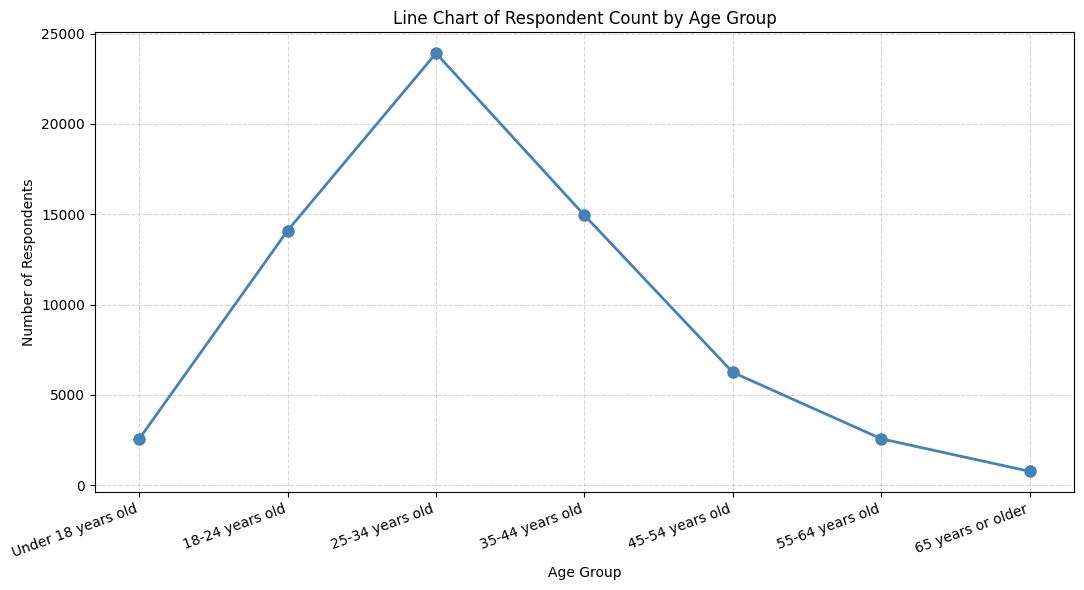

In [14]:
# Query respondent count grouped by age
QUERY = 'SELECT Age, COUNT(*) as count FROM main GROUP BY Age'
df_line = pd.read_sql_query(QUERY, conn)

# Define and apply correct category order
age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old',
    '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older'
]
df_line = df_line[df_line['Age'].isin(age_order)].copy()
df_line['Age'] = pd.Categorical(df_line['Age'], categories=age_order, ordered=True)
df_line = df_line.sort_values('Age')

# Render the line chart
plt.figure(figsize=(11, 6))
plt.plot(df_line['Age'], df_line['count'], marker='o',
         linewidth=2, color='steelblue', markersize=8)
plt.title('Line Chart of Respondent Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=20, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


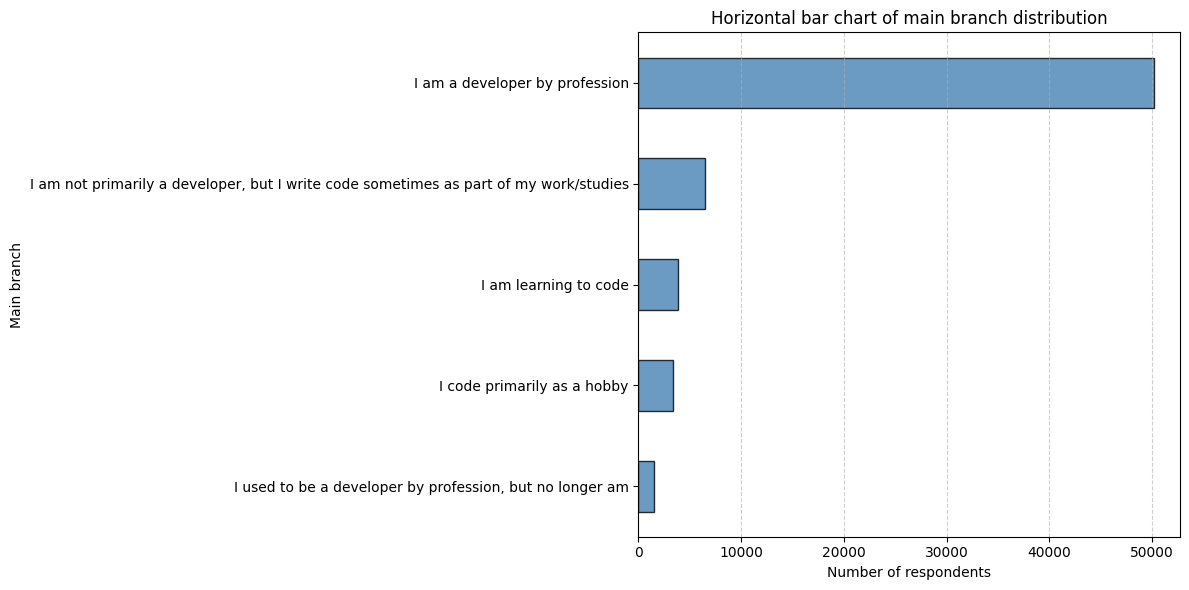

In [26]:
# Extract the requisite column from the database
QUERY = 'SELECT MainBranch FROM main'
df_branch = pd.read_sql_query(QUERY, conn)

# Ascertain the frequency distribution of the categorical responses
branch_counts = df_branch['MainBranch'].value_counts(dropna=True)

# Render the horizontal bar visualization
plt.figure(figsize=(12, 6))
branch_counts.plot(kind='barh', color='steelblue', edgecolor='black', alpha=0.8)

# Invert the y-axis to position the highest frequency category at the top
plt.gca().invert_yaxis()

plt.title('Horizontal bar chart of main branch distribution')
plt.xlabel('Number of respondents')
plt.ylabel('Main branch')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
